# Policy Lever Impact Analysis

This notebook evaluates how key policy levers affect permitting outcomes.

Levers included:
- Staffing levels (planning, public works, fire)
- Application arrival timing (`inter_arrival_time`)
- Permit volume (`num_permits`)

For each scenario, the notebook runs multiple Monte Carlo repetitions and summarizes impacts on:
- Mean total processing time
- Median total processing time
- Completion count
- Mean staff utilization (planning, public works, fire)


In [9]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from run_simulation import run_multiple_simulations, plot_staff_utilization_series

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [10]:
# --- Baseline + policy scenario grid ---
BASE_PARAMS = {
    "name": "baseline",
    "sequential": "standard",
    "ai_review": "none",
    "pct_pre_approved": 0.018,
    "pct_custom": 0.91,
    "pct_self_cert": 0.081,
    "pct_like_for_like": 0.803,
    "pre_application_distribution": "baseline",
    "review_duration_families": None,
    "review_duration_multipliers": None,
    "planning_staff_count": 20,
    "planning_caseload_per_staff": 7,
    "public_works_staff_count": 30,
    "public_works_caseload_per_staff": 7,
    "fire_staff_count": 10,
    "fire_caseload_per_staff": 7,
}

N_RUNS = 20
BASE_SEED = 42
SIMULATION_DURATION = None

NUM_PERMITS_OPTIONS = [2000, 6500]
INTER_ARRIVAL_OPTIONS = [0.0]

# Scenario dimensions (not policy levers)
STAFFING_SCENARIOS = {
    "low": {"planning_staff_count": 2, "public_works_staff_count": 3, "fire_staff_count": 1},
    "medium": {"planning_staff_count": 8, "public_works_staff_count": 12, "fire_staff_count": 4},
    "high": {"planning_staff_count": 20, "public_works_staff_count": 30, "fire_staff_count": 10},
}
PRE_APPLICATION_DISTRIBUTIONS = ["lognormal_10", "lognormal_60", "lognormal_180"]

# Policy levers
SEQUENTIAL_OPTIONS = ["sequential", "standard", "parallel"]
AI_REVIEW_OPTIONS = ["none", "initial_check", "full_review"]


def build_scenarios():
    scenarios = []
    for (
        num_permits,
        inter_arrival,
        (staffing_name, staffing),
        pre_app_dist,
        sequential_mode,
        ai_mode,
    ) in itertools.product(
        NUM_PERMITS_OPTIONS,
        INTER_ARRIVAL_OPTIONS,
        STAFFING_SCENARIOS.items(),
        PRE_APPLICATION_DISTRIBUTIONS,
        SEQUENTIAL_OPTIONS,
        AI_REVIEW_OPTIONS,
    ):
        scenario = dict(BASE_PARAMS)
        scenario["name"] = (
            f"permits={num_permits}|ia={inter_arrival}|staffing={staffing_name}|"
            f"preapp={pre_app_dist}|seq={sequential_mode}|ai={ai_mode}"
        )
        scenario["planning_staff_count"] = staffing["planning_staff_count"]
        scenario["public_works_staff_count"] = staffing["public_works_staff_count"]
        scenario["fire_staff_count"] = staffing["fire_staff_count"]
        scenario["pre_application_distribution"] = pre_app_dist
        scenario["sequential"] = sequential_mode
        scenario["ai_review"] = ai_mode
        scenarios.append((num_permits, inter_arrival, staffing_name, pre_app_dist, sequential_mode, ai_mode, scenario))
    return scenarios


SCENARIOS = build_scenarios()
print(f"Total scenarios: {len(SCENARIOS)}")
print("Staffing scenarios:", list(STAFFING_SCENARIOS.keys()))
print("Pre-application distributions:", PRE_APPLICATION_DISTRIBUTIONS)
print("Policy levers:")
print("  sequential:", SEQUENTIAL_OPTIONS)
print("  ai_review:", AI_REVIEW_OPTIONS)


Total scenarios: 72
Staffing scenarios: ['low', 'medium', 'high']
Pre-application distributions: ['lognormal_10', 'lognormal_60', 'lognormal_180']
Policy levers:
  sequential: ['parallel', 'sequential']
  ai_review: ['initial_check', 'full_review']


In [11]:
# --- Run experiments ---
rows = []
util_by_scenario = {}

for idx, (num_permits, inter_arrival, staffing_name, pre_app_dist, sequential_mode, ai_mode, scenario) in enumerate(SCENARIOS, start=1):
    results, avg_util_by_scenario = run_multiple_simulations(
        n_runs=N_RUNS,
        num_permits=num_permits,
        simulation_duration=SIMULATION_DURATION,
        inter_arrival_time=inter_arrival,
        base_seed=BASE_SEED,
        scenario_params_list=[scenario],
        collect_permits=True,
        collect_average_staff_utilization=True,
        utilization_step=0.1,
    )

    util = avg_util_by_scenario[scenario["name"]]
    util_by_scenario[scenario["name"]] = util

    app_to_ready_mean_by_run = []
    app_to_ready_median_by_run = []
    completed_by_run = []

    for r in results:
        permits = r.get("permits", [])
        durations = [
            (p.ready_for_construction - p.planning_request)
            for p in permits
            if p.ready_for_construction is not None and p.planning_request is not None
        ]
        if durations:
            app_to_ready_mean_by_run.append(float(np.mean(durations)))
            app_to_ready_median_by_run.append(float(np.median(durations)))
        else:
            app_to_ready_mean_by_run.append(np.nan)
            app_to_ready_median_by_run.append(np.nan)
        completed_by_run.append(len(durations))

    rows.append(
        {
            "scenario": scenario["name"],
            "num_permits": num_permits,
            "inter_arrival_time": inter_arrival,
            "staffing_scenario": staffing_name,
            "pre_application_distribution": pre_app_dist,
            "sequential": sequential_mode,
            "ai_review": ai_mode,
            "planning_staff_count": scenario["planning_staff_count"],
            "public_works_staff_count": scenario["public_works_staff_count"],
            "fire_staff_count": scenario["fire_staff_count"],
            "application_to_ready_mean_days": float(np.nanmean(app_to_ready_mean_by_run)),
            "application_to_ready_mean_days_std": float(np.nanstd(app_to_ready_mean_by_run, ddof=1) if len(app_to_ready_mean_by_run) > 1 else 0.0),
            "application_to_ready_median_days": float(np.nanmean(app_to_ready_median_by_run)),
            "completed_mean": float(np.mean(completed_by_run)),
            "planning_util_mean_pct": float(100.0 * np.mean(util["planning"])),
            "planning_util_peak_pct": float(100.0 * np.max(util["planning"])),
            "public_works_util_mean_pct": float(100.0 * np.mean(util["public_works"])),
            "public_works_util_peak_pct": float(100.0 * np.max(util["public_works"])),
            "fire_util_mean_pct": float(100.0 * np.mean(util["fire"])),
            "fire_util_peak_pct": float(100.0 * np.max(util["fire"])),
        }
    )

    if idx % 10 == 0 or idx == len(SCENARIOS):
        print(f"Completed {idx}/{len(SCENARIOS)} scenarios")

impact_df = pd.DataFrame(rows)
impact_df.head()


Completed 10/72 scenarios
Completed 20/72 scenarios
Completed 30/72 scenarios
Completed 40/72 scenarios
Completed 50/72 scenarios
Completed 60/72 scenarios
Completed 70/72 scenarios
Completed 72/72 scenarios


,scenario,num_permits,inter_arrival_time,staffing_scenario,pre_application_distribution,sequential,ai_review,planning_staff_count,public_works_staff_count,fire_staff_count,application_to_ready_mean_days,application_to_ready_mean_days_std,application_to_ready_median_days,completed_mean,planning_util_mean_pct,planning_util_peak_pct,public_works_util_mean_pct,public_works_util_peak_pct,fire_util_mean_pct,fire_util_peak_pct
0,permits=2000|ia=0.0|staffing=low|preapp=lognor...,2000,0.0,low,lognormal_10,parallel,initial_check,2,3,1,550.864184,12.978515,548.918912,2000.0,14.458768,100.0,11.656543,100.000000,21.441814,100.0
1,permits=2000|ia=0.0|staffing=low|preapp=lognor...,2000,0.0,low,lognormal_10,parallel,full_review,2,3,1,549.669834,11.602094,547.719744,2000.0,1.940247,100.0,1.589273,100.000000,21.436157,100.0
2,permits=2000|ia=0.0|staffing=low|preapp=lognor...,2000,0.0,low,lognormal_10,sequential,initial_check,2,3,1,617.255527,11.216114,617.344219,2000.0,14.457468,100.0,11.680904,84.523810,21.344445,100.0
3,permits=2000|ia=0.0|staffing=low|preapp=lognor...,2000,0.0,low,lognormal_10,sequential,full_review,2,3,1,563.409386,12.029795,563.195365,2000.0,1.941525,100.0,1.588525,74.285714,21.439428,100.0
4,permits=2000|ia=0.0|staffing=low|preapp=lognor...,2000,0.0,low,lognormal_60,parallel,initial_check,2,3,1,512.134244,11.243122,510.436272,2000.0,14.450411,100.0,11.673547,100.000000,21.348016,100.0


In [12]:
# --- Policy lever impacts (parallel vs sequential, AI initial vs full) ---
def effect_span(df, lever, metric):
    grouped = df.groupby(lever, as_index=False)[metric].mean().sort_values(lever)
    return grouped, grouped[metric].max() - grouped[metric].min()

metrics = [
    "application_to_ready_mean_days",
    "application_to_ready_median_days",
    "planning_util_mean_pct",
    "public_works_util_mean_pct",
    "fire_util_mean_pct",
]

policy_levers = ["sequential", "ai_review"]

for metric in metrics:
    print("\n" + "=" * 90)
    print(f"Metric: {metric}")
    print("=" * 90)
    spans = []
    for lever in policy_levers:
        grouped, span = effect_span(impact_df, lever, metric)
        spans.append((lever, span))
        print(f"\nPolicy lever: {lever} (span={span:.2f})")
        display(grouped)

    print("\nPolicy lever rank by effect span:")
    for lever, span in sorted(spans, key=lambda x: x[1], reverse=True):
        print(f"  {lever:24s} {span:10.2f}")

print("\n" + "=" * 90)
print("Policy levers within each staffing / permit / pre-app scenario")
print("=" * 90)
strata_cols = ["num_permits", "staffing_scenario", "pre_application_distribution"]
for keys, group in impact_df.groupby(strata_cols):
    print(f"\nStratum: permits={keys[0]}, staffing={keys[1]}, pre_app={keys[2]}")
    pivot = group.pivot_table(
        index="sequential",
        columns="ai_review",
        values="application_to_ready_mean_days",
        aggfunc="mean",
    )
    display(pivot)



Metric: application_to_ready_mean_days

Policy lever: sequential (span=34.46)


,sequential,application_to_ready_mean_days
0,parallel,502.633805
1,sequential,537.095180



Policy lever: ai_review (span=24.79)


,ai_review,application_to_ready_mean_days
0,full_review,507.467255
1,initial_check,532.261730



Policy lever rank by effect span:
  sequential                    34.46
  ai_review                     24.79

Metric: application_to_ready_median_days

Policy lever: sequential (span=33.24)


...

ai_review,full_review,initial_check
sequential,,
parallel,527.910123,535.169215
sequential,474.207235,529.373179



Stratum: permits=6500, staffing=medium, pre_app=lognormal_180


ai_review,full_review,initial_check
sequential,,
parallel,344.967172,396.398173
sequential,376.894895,426.697650



Stratum: permits=6500, staffing=medium, pre_app=lognormal_60


ai_review,full_review,initial_check
sequential,,
parallel,464.597487,500.876556
sequential,454.086150,519.889667


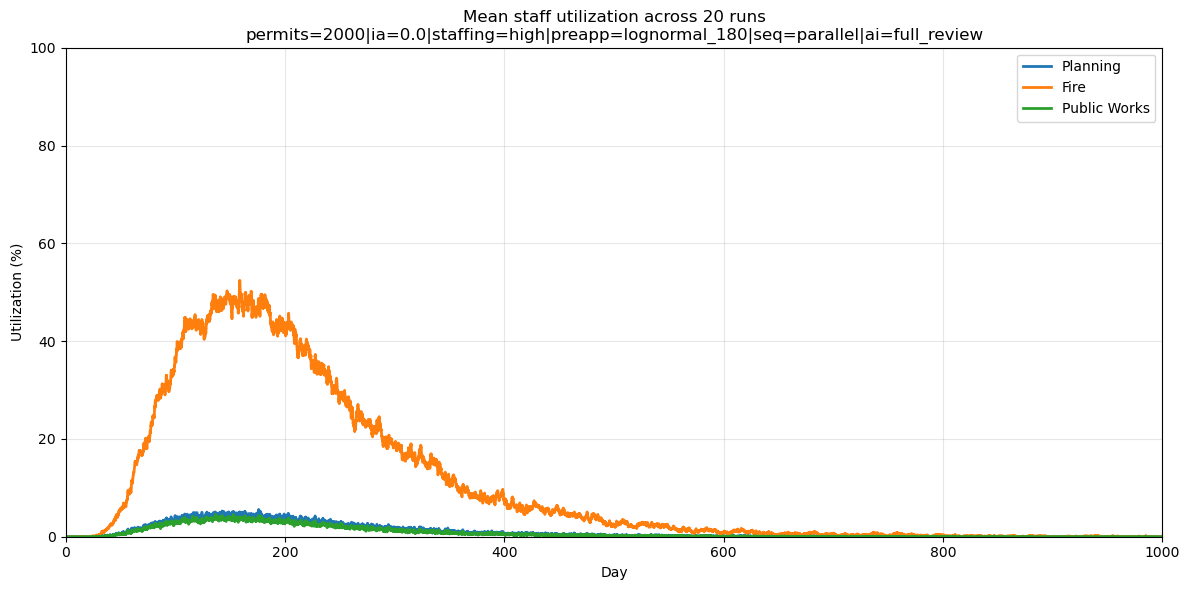

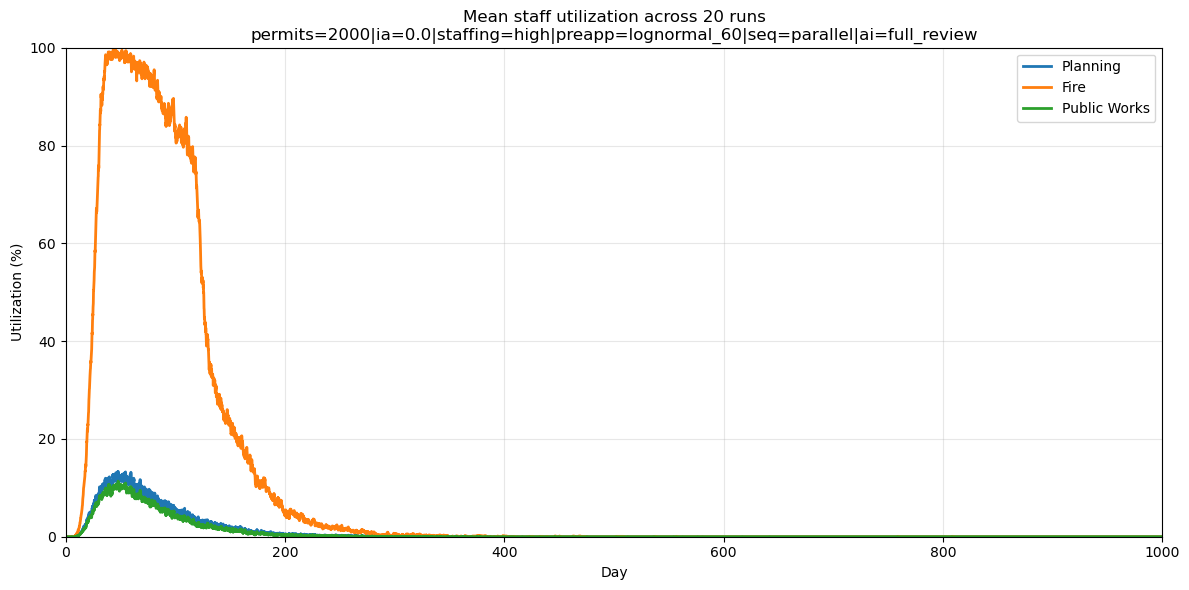

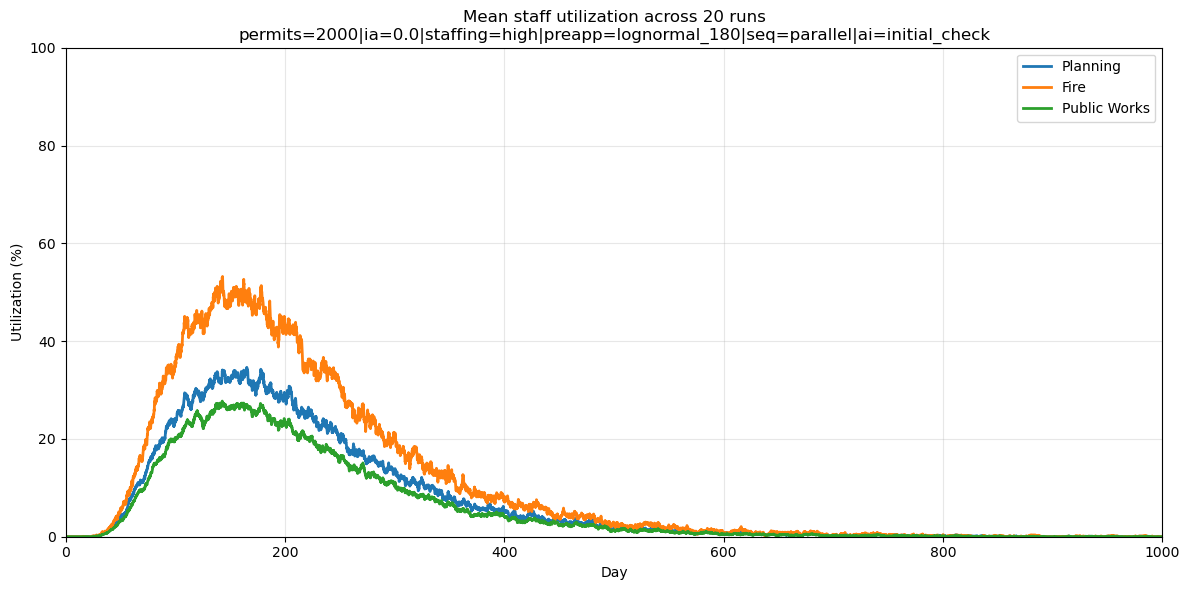

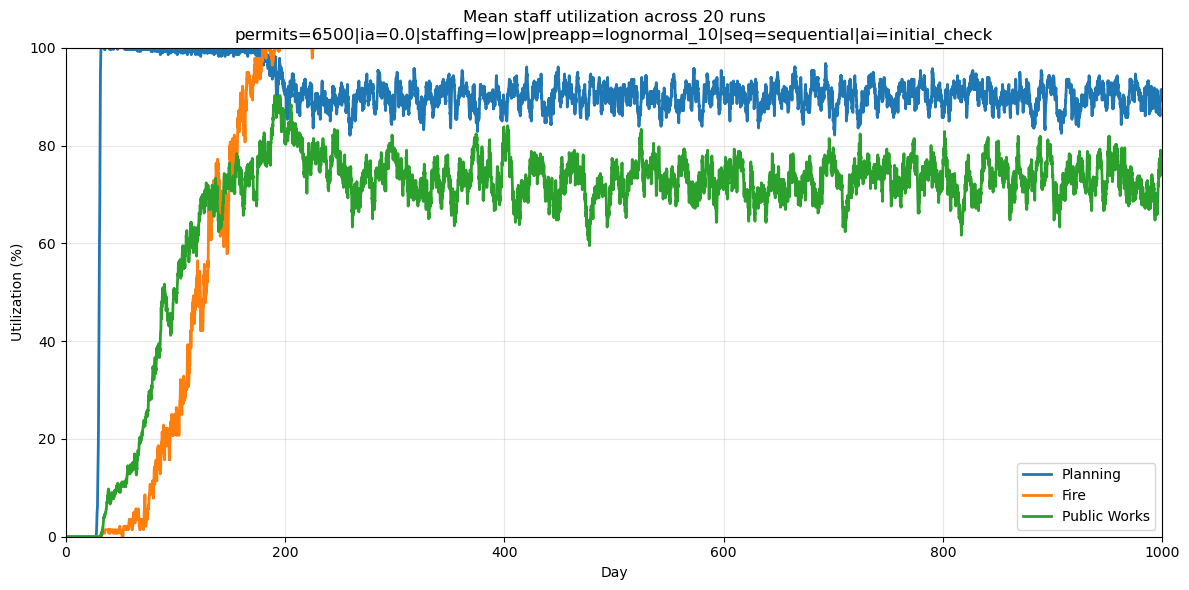

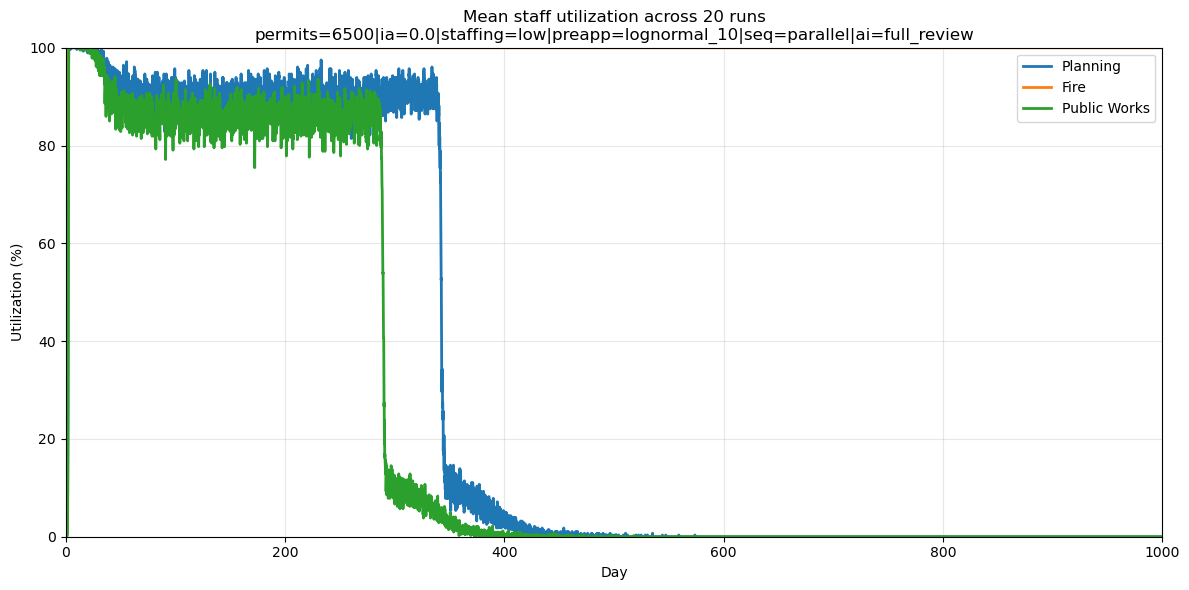

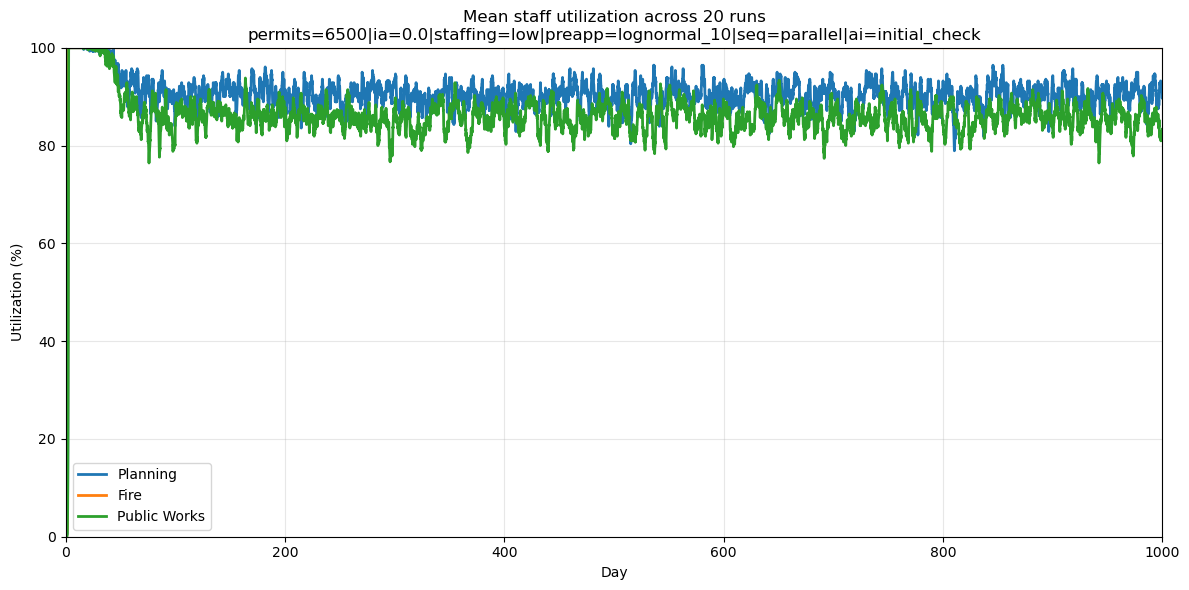

In [13]:
# --- Plot average utilization for selected scenarios ---
# Pick a few scenarios to compare; adjust list as needed.
selected = impact_df.sort_values("application_to_ready_mean_days").head(3)["scenario"].tolist()
selected += impact_df.sort_values("application_to_ready_mean_days", ascending=False).head(3)["scenario"].tolist()
selected = list(dict.fromkeys(selected))

for scenario_name in selected:
    util = util_by_scenario[scenario_name]
    plot_staff_utilization_series(
        util,
        as_percent=True,
        title=f"Mean staff utilization across {util['n_runs']} runs\n{scenario_name}",
        xlim=(0, min(1000, util["max_day"])),
        ylim=(0, 100),
    )


In [14]:
# --- Save results for reuse ---
from pathlib import Path

results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

output_path = results_dir / "policy_lever_impact_results.csv"
impact_df.to_csv(output_path, index=False)
print(f"Saved: {output_path}")


Saved: policy_lever_impact_results.csv
